# Stage 2: DenseNet-121 — 5-Fold Cross-Validation

## Giriş ve Metodoloji
Bu notebook, inme arter sınıflandırması (ACA/MCA/PCA) için geliştirilen DenseNet-121 modelinin **bilimsel geçerliliğini ve kararlılığını (stability)** ölçmek amacıyla hazırlanmıştır.

Önceki deneylerde tek bir `train/val` ayrımı (split) ile yüksek skorlar elde edilmiştir. Ancak veri setindeki ciddi dengesizlik (ACA: %8.1) ve küçük örneklem boyutu nedeniyle, bu skorların "şanslı bir veri dağılımına" denk gelme ihtimali vardır.

Bu riski elimine etmek için **Stratified 5-Fold Cross-Validation** uygulanacaktır.

### Süreç Akışı
1.  **Test Seti Ayrımı:** Verinin %15'i "Hold-out Test Set" olarak en başta ayrılır ve CV döngüsüne **asla** dahil edilmez.
2.  **Cross-Validation:** Kalan %85'lik veri, sınıf oranları korunarak 5 parçaya (Fold) bölünür.
3.  **Döngü (5 Kez):**
    *   Model sıfırdan oluşturulur.
    *   4 parça ile eğitim, 1 parça ile doğrulama yapılır.
    *   Her fold için `WeightedRandomSampler` yeniden hesaplanır.
    *   En iyi model `best_model_fold_X.pth` olarak kaydedilir.
4.  **Raporlama:** 5 eğitimin ortalaması ve standart sapması raporlanır.

## Bölüm 1: Setup & Imports

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
import torchvision
from torchvision import models

# Albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

# Metrics & Selection
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from tqdm import tqdm
from collections import Counter

# --- REPRODUCIBILITY SETUP ---
SEED = 42

def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

set_seed(SEED)
g = torch.Generator()
g.manual_seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Bölüm 2: Sabitler

In [2]:
# --- PATHS ---
STROKE_IMAGES_DIR = '/kaggle/input/stroke-images/flattened_images'

# --- CLASS INFO ---
CLASS_NAMES = ['ACA', 'MCA', 'PCA']
NUM_CLASSES = len(CLASS_NAMES)

# --- HYPERPARAMETERS ---
IMG_SIZE = 224
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 50      # CV olduğu için epoch sayısını biraz düşürebiliriz (zaman tasarrufu)
PATIENCE = 10        # Patience da düşürüldü
N_FOLDS = 5          # 5-Fold CV

print(f'=== 5-Fold CV Parametreleri ===')
print(f'Model: DenseNet-121')
print(f'Fold Sayısı: {N_FOLDS}')
print(f'Epochs per Fold: {NUM_EPOCHS}')

=== 5-Fold CV Parametreleri ===
Model: DenseNet-121
Fold Sayısı: 5
Epochs per Fold: 50


## Bölüm 3: Veri Hazırlığı ve Hold-out Split

In [3]:
def collect_stroke_image_paths(stroke_dir, class_names):
    image_paths = []
    labels = []
    for idx, class_name in enumerate(class_names):
        class_dir = Path(stroke_dir) / class_name
        if not class_dir.exists(): continue
        
        extensions = ['*.png', '*.jpg', '*.jpeg']
        class_images = []
        for ext in extensions:
            class_images.extend(list(class_dir.glob(ext)))
            
        for img_path in class_images:
            image_paths.append(str(img_path))
            labels.append(idx)
    return np.array(image_paths), np.array(labels)

all_image_paths, all_labels = collect_stroke_image_paths(STROKE_IMAGES_DIR, CLASS_NAMES)

# 1. Adım: %15 Test setini tamamen ayır (Final Evaluation için)
# Geriye kalan %85'i CV için kullanacağız.
X_cv, X_test, y_cv, y_test = train_test_split(
    all_image_paths, all_labels, 
    test_size=0.15, 
    stratify=all_labels, 
    random_state=SEED
)

print(f'Toplam Veri: {len(all_image_paths)}')
print(f'CV İçin Ayrılan (Train+Val): {len(X_cv)}')
print(f'Hold-out Test Seti: {len(X_test)}')

Toplam Veri: 4609
CV İçin Ayrılan (Train+Val): 3917
Hold-out Test Seti: 692


## Bölüm 4: Augmentation & Dataset Class

In [4]:
# Augmentasyonlar (Aynı)
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.ElasticTransform(alpha=50, sigma=50 * 0.05, p=0.3),
    A.GridDistortion(num_steps=5, distort_limit=0.1, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# =========================
# HIZLANDIRILMIŞ DATASET (RAM CACHING)
# =========================
class StrokeDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.images = [] # Resimleri burada tutacağız
        
        # Tüm resimleri baştan RAM'e yüklüyoruz (Pre-loading)
        print(f"Veriler RAM'e yükleniyor ({len(image_paths)} adet)...")
        for img_path in tqdm(self.image_paths, desc="Loading Images"):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            self.images.append(img)
            
    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Diskten okuma YOK, direkt RAM'den alıyoruz
        image = self.images[idx]
        label = int(self.labels[idx])

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, label

## Bölüm 5: Model ve Eğitim Yardımcıları

In [5]:
def create_model():
    # Her fold için modeli sıfırdan oluşturacağız
    weights = models.DenseNet121_Weights.IMAGENET1K_V1
    model = models.densenet121(weights=weights)
    num_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(num_features, NUM_CLASSES)
    )
    return model

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    return running_loss / total, correct / total

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    return running_loss / total, correct / total, np.array(all_preds), np.array(all_labels)

## Bölüm 6: 5-Fold Cross-Validation Döngüsü

In [6]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Sonuçları saklamak için
fold_results = []
cv_history = {}

print(f'=== {N_FOLDS}-Fold Cross Validation Başlıyor ===\n')

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cv, y_cv)):
    print(f'FOLD {fold+1}/{N_FOLDS}')
    print('-' * 40)
    
    # 1. Veri Hazırlığı (Bu fold için)
    X_train_fold = X_cv[train_idx]
    y_train_fold = y_cv[train_idx]
    X_val_fold = X_cv[val_idx]
    y_val_fold = y_cv[val_idx]
    
    # Dataset
    train_ds = StrokeDataset(X_train_fold, y_train_fold, transform=train_transform)
    val_ds = StrokeDataset(X_val_fold, y_val_fold, transform=val_transform)
    
    # Sampler (Bu fold'un eğitim verisine özel hesaplanmalı!)
    class_counts = Counter(y_train_fold)
    class_weights = {c: 1.0/cnt for c, cnt in class_counts.items()}
    sample_weights = [class_weights[y] for y in y_train_fold]
    
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    
    # DataLoader
    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, sampler=sampler, 
        num_workers=4, pin_memory=True, worker_init_fn=seed_worker, generator=g
    )
    val_loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE, shuffle=False, 
        num_workers=4, pin_memory=True, worker_init_fn=seed_worker, generator=g
    )
    
    # 2. Model & Optimizer (Sıfırdan Başlat)
    model = create_model().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    # 3. Eğitim Döngüsü
    best_loss = float('inf')
    patience_cnt = 0
    fold_history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    # Tqdm ile epoch takibi
    pbar = tqdm(range(NUM_EPOCHS), desc=f'Fold {fold+1}', leave=True)
    
    for epoch in pbar:
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        v_loss, v_acc, _, _ = validate(model, val_loader, criterion, device)
        
        scheduler.step(v_loss)
        
        fold_history['train_loss'].append(t_loss)
        fold_history['val_loss'].append(v_loss)
        fold_history['val_acc'].append(v_acc)
        
        pbar.set_postfix({'v_loss': f'{v_loss:.4f}', 'v_acc': f'{v_acc:.2f}'})
        
        # Checkpoint
        if v_loss < best_loss:
            best_loss = v_loss
            patience_cnt = 0
            torch.save(model.state_dict(), f'densenet_fold{fold+1}.pth')
        else:
            patience_cnt += 1
            
        if patience_cnt >= PATIENCE:
            break
            
    # 4. Fold Değerlendirmesi (En iyi model ile)
    model.load_state_dict(torch.load(f'densenet_fold{fold+1}.pth'))
    _, val_acc, val_preds, val_labels = validate(model, val_loader, criterion, device)
    
    # Metrikler
    fold_rep = classification_report(val_labels, val_preds, target_names=CLASS_NAMES, output_dict=True)
    
    print(f'\nFold {fold+1} Sonuçları:')
    print(f'  Val Acc: {val_acc*100:.2f}%')
    print(f'  ACA Recall: {fold_rep["ACA"]["recall"]:.4f}')
    print(f'  MCA Recall: {fold_rep["MCA"]["recall"]:.4f}')
    print(f'  PCA Recall: {fold_rep["PCA"]["recall"]:.4f}')
    
    fold_results.append({
        'fold': fold+1,
        'accuracy': val_acc,
        'aca_recall': fold_rep['ACA']['recall'],
        'mca_recall': fold_rep['MCA']['recall'],
        'pca_recall': fold_rep['PCA']['recall'],
        'macro_f1': fold_rep['macro avg']['f1-score']
    })
    
    cv_history[f'fold{fold+1}'] = fold_history
    print('=' * 40 + '\n')

print('Cross-Validation Tamamlandı.')

=== 5-Fold Cross Validation Başlıyor ===

FOLD 1/5
----------------------------------------
Veriler RAM'e yükleniyor (3133 adet)...


Loading Images: 100%|██████████| 3133/3133 [01:00<00:00, 51.61it/s]


Veriler RAM'e yükleniyor (784 adet)...


Loading Images: 100%|██████████| 784/784 [00:15<00:00, 51.67it/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


...


Fold 4 Sonuçları:
  Val Acc: 84.29%
  ACA Recall: 0.7302
  MCA Recall: 0.8885
  PCA Recall: 0.7317

FOLD 5/5
----------------------------------------
Veriler RAM'e yükleniyor (3134 adet)...


Loading Images: 100%|██████████| 3134/3134 [00:52<00:00, 59.44it/s]


Veriler RAM'e yükleniyor (783 adet)...


Fold 5:  64%|██████▍   | 32/50 [22:47<12:49, 42.73s/it, v_loss=0.3593, v_acc=0.90]



Fold 5 Sonuçları:
  Val Acc: 90.68%
  ACA Recall: 0.6984
  MCA Recall: 0.9604
  PCA Recall: 0.8049

Cross-Validation Tamamlandı.


## Bölüm 7: CV Sonuç Analizi ve Raporlama

=== 5-FOLD CROSS-VALIDATION SONUÇLARI ===
   fold  accuracy  aca_recall  mca_recall  pca_recall  macro_f1
0     1  0.877551    0.730159    0.920863    0.787879  0.819665
1     2  0.875000    0.765625    0.900901    0.830303  0.811808
2     3  0.855683    0.666667    0.877477    0.854545  0.796876
3     4  0.842912    0.730159    0.888489    0.731707  0.768797
4     5  0.906769    0.698413    0.960432    0.804878  0.838062

=== ORTALAMA PERFORMANS ===
Accuracy:   0.8716 ± 0.0243
ACA Recall: 0.7182 ± 0.0374
MCA Recall: 0.9096 ± 0.0326
PCA Recall: 0.8019 ± 0.0467
Macro F1:   0.8070 ± 0.0260


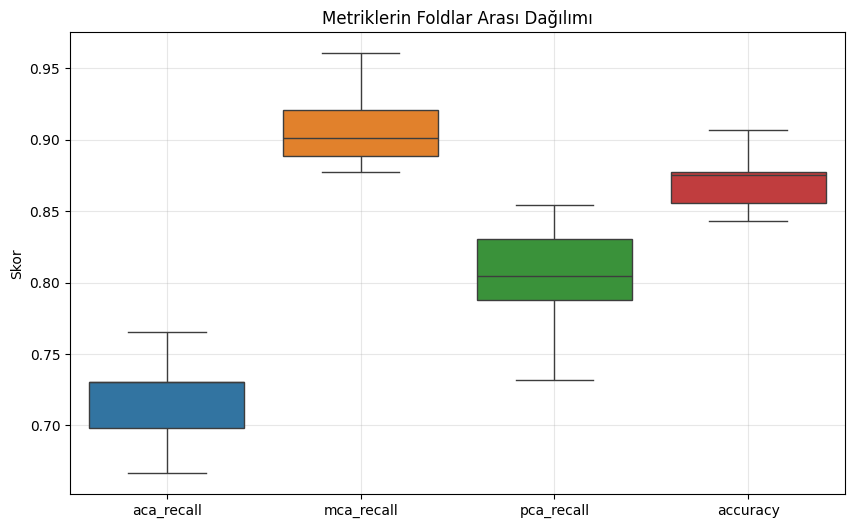

In [7]:
# Sonuçları DataFrame'e çevir
df_results = pd.DataFrame(fold_results)

print('=== 5-FOLD CROSS-VALIDATION SONUÇLARI ===')
print(df_results)

print('\n=== ORTALAMA PERFORMANS ===')
print(f"Accuracy:   {df_results['accuracy'].mean():.4f} ± {df_results['accuracy'].std():.4f}")
print(f"ACA Recall: {df_results['aca_recall'].mean():.4f} ± {df_results['aca_recall'].std():.4f}")
print(f"MCA Recall: {df_results['mca_recall'].mean():.4f} ± {df_results['mca_recall'].std():.4f}")
print(f"PCA Recall: {df_results['pca_recall'].mean():.4f} ± {df_results['pca_recall'].std():.4f}")
print(f"Macro F1:   {df_results['macro_f1'].mean():.4f} ± {df_results['macro_f1'].std():.4f}")

# Boxplot ile dağılımı göster
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_results[['aca_recall', 'mca_recall', 'pca_recall', 'accuracy']])
plt.title('Metriklerin Foldlar Arası Dağılımı')
plt.ylabel('Skor')
plt.grid(True, alpha=0.3)
plt.show()

## Bölüm 8: Hold-out Test Seti Değerlendirmesi

En başarılı model: Fold 5 (Macro F1: 0.8381)
Hold-out Test Seti üzerinde değerlendiriliyor...
Veriler RAM'e yükleniyor (692 adet)...


Loading Images: 100%|██████████| 692/692 [00:16<00:00, 43.10it/s]



Final Test Accuracy: 89.45%

Classification Report (Test Set):
              precision    recall  f1-score   support

         ACA     0.7843    0.7143    0.7477        56
         MCA     0.9235    0.9348    0.9291       491
         PCA     0.8333    0.8276    0.8304       145

    accuracy                         0.8945       692
   macro avg     0.8471    0.8256    0.8358       692
weighted avg     0.8934    0.8945    0.8938       692



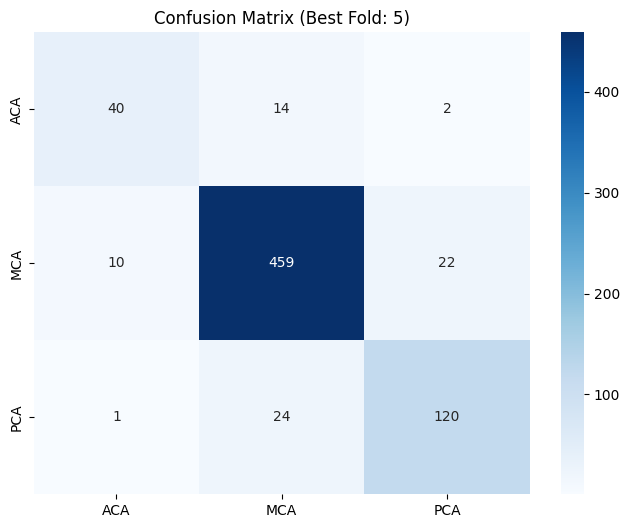

In [8]:
# En iyi fold modelini seç
best_fold_idx = df_results['macro_f1'].idxmax()
best_fold_num = df_results.loc[best_fold_idx, 'fold']

print(f'En başarılı model: Fold {best_fold_num} (Macro F1: {df_results.loc[best_fold_idx, "macro_f1"]:.4f})')
print('Hold-out Test Seti üzerinde değerlendiriliyor...')

# Test Dataset & Loader
test_ds = StrokeDataset(X_test, y_test, transform=val_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# Modeli Yükle
model = create_model().to(device)
model.load_state_dict(torch.load(f'densenet_fold{best_fold_num}.pth'))

# Test
_, test_acc, test_preds, test_labels = validate(model, test_loader, nn.CrossEntropyLoss(), device)

print(f'\nFinal Test Accuracy: {test_acc*100:.2f}%')
print('\nClassification Report (Test Set):')
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Confusion Matrix (Best Fold: {best_fold_num})')
plt.show()